<a href="https://colab.research.google.com/github/HimaVarshitha7/Ai-Chat/blob/main/Internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [ ]:
print("First 5 rows of the dataset:")
print(df.head(5))

First 5 rows of the dataset:
    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0 

In [ ]:
print("\nDataFrame shape (rows, columns):",df.shape)


DataFrame shape (rows, columns): (299, 13)


In [ ]:
print("\n Data Frame Information:")
print(df.info())


 Data Frame Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 

In [ ]:
print("\n Statistical Summary of a numerical features:")
print(df.describe())


 Statistical Summary of a numerical features:
              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000

In [ ]:
target_counts = df['DEATH_EVENT'].value_counts()
print("\n Distribution of HeartDisease variables:")
print(target_counts)


 Distribution of HeartDisease variables:
DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


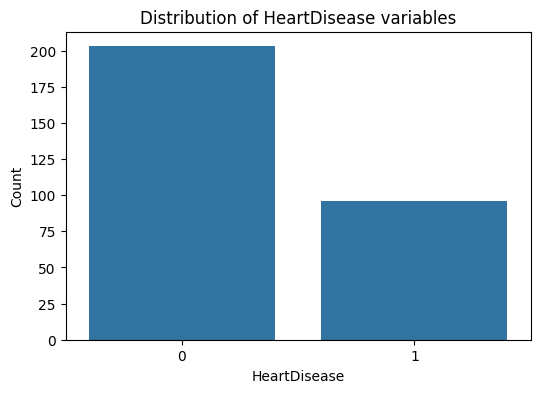

In [ ]:
plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values)
plt.xlabel('HeartDisease')
plt.ylabel('Count')
plt.title('Distribution of HeartDisease variables')
plt.show()


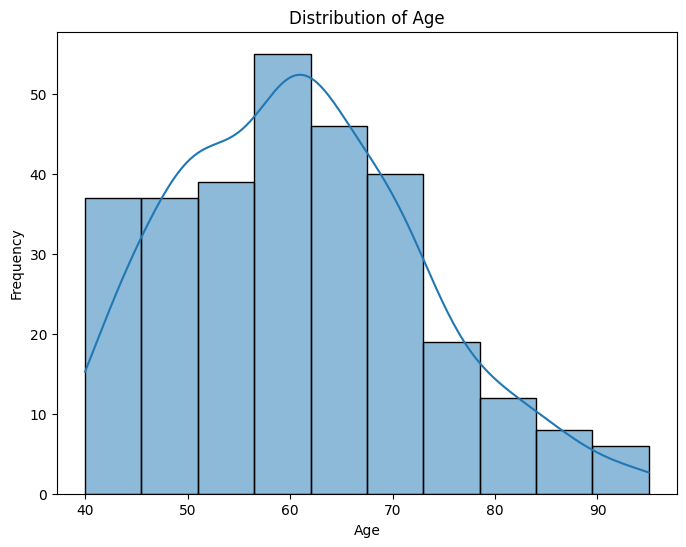

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['age'], kde=True)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age')
plt.show()

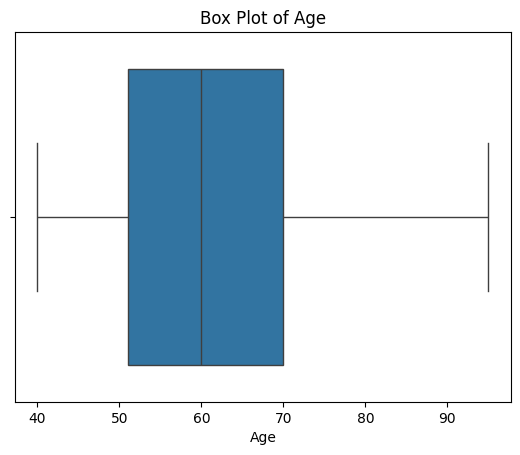

In [ ]:
sns.boxplot(x=df['age'])
plt.xlabel('Age')
plt.title('Box Plot of Age')
plt.show()

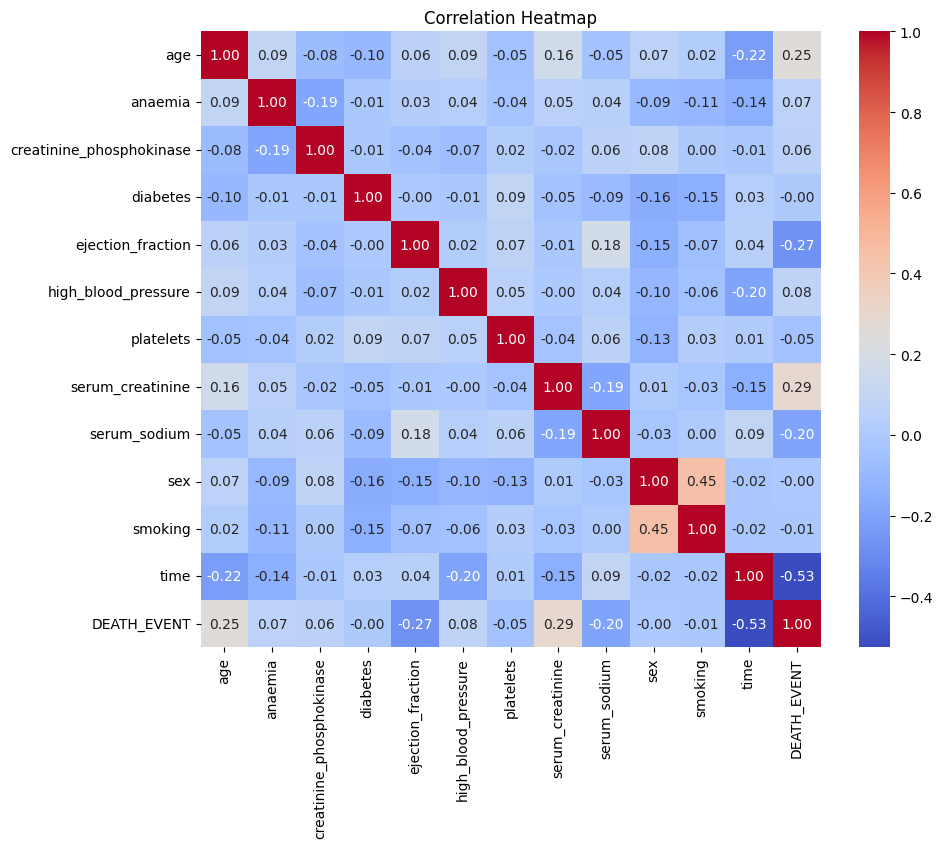

In [ ]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
print(df.columns.tolist())


['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT']


In [ ]:
# Fill missing Age values with median
median_age = df['age'].median()
df['age'] = df['age'].fillna(median_age)

In [ ]:
# Fill missing Heart Disease values with mode
mode_target = df['DEATH_EVENT'].mode()[0]
df['DEATH_EVENT'] = df['DEATH_EVENT'].fillna(mode_target)

In [ ]:
# Print missing values after imputation
print("\nMissing values after imputation:")
print(df.isnull().sum())


Missing values after imputation:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [ ]:
# Calculate IQR for Age
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

# Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_cleaned = df[(df['age'] >= lower_bound) & (df['age'] <= upper_bound)]

print(f"\nOriginal DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape after outlier removal: {df_cleaned.shape}")


Original DataFrame shape: (299, 13)
Cleaned DataFrame shape after outlier removal: (299, 13)


In [ ]:
def clean_data(data, column):
    cleaned_df = data.copy()
    Q1 = cleaned_df[column].quantile(0.25)
    Q3 = cleaned_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    return cleaned_df[(cleaned_df[column] >= lower_bound) &
                      (cleaned_df[column] <= upper_bound)]

# Example usage
df_cleaned = clean_data(df, 'age')
print(f"\nOriginal: {df.shape}, Cleaned: {df_cleaned.shape}")



Original: (299, 13), Cleaned: (299, 13)


In [ ]:
def clean_data(data):
    cleaned_df = data.copy()

    for col in cleaned_df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = cleaned_df[col].quantile(0.25)
        Q3 = cleaned_df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Keep only values within bounds
        cleaned_df = cleaned_df[(cleaned_df[col] >= lower_bound) & (cleaned_df[col] <= upper_bound)]

    return cleaned_df


# Example usage
df_cleaned = clean_data(df)
print(f"\nOriginal DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape after outlier removal: {df_cleaned.shape}")


Original DataFrame shape: (299, 13)
Cleaned DataFrame shape after outlier removal: (224, 13)


Day 4: OCR System Development

In [ ]:
!pip install pytesseract Pillow opencv-python

import pytesseract
from PIL import Image
import cv2
import re



In [ ]:
image_path = 'sample_medical_document.png'
image = cv2.imread(image_path)

In [ ]:
import cv2
import pytesseract
from PIL import Image
import re

# Correct image path (make sure the file exists in your working directory)
image_path = "sample_medical_document.png"  # Replace with your actual file name

# Try to read the image
image = cv2.imread(image_path)

if image is None:
    print("❌ Error: Could not load image. Check the file path and format.")
else:
    # Convert to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    ret , thresh_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    # OCR
    text = pytesseract.image_to_string(thresh_image, lang='eng',config='--psm 6')
    print("✅ Extracted Text:")
    print(text)


✅ Extracted Text:
Patient mane: gohn Doe

age 54

ender wale

Patient m= 312945

Medical Examination: Meart Disease Risk
Blood Pressure: 150 / 95 wnity
cholesterol 245 gia.

Blood sugar 132 ng/an.

smoking yes

Exereise Rarely

Fanily Mistory : Positive (Father - Neart Disease)
Doctor’ s notes:

he patient shows multiple risk factors
Including hypertension, high cholesterol,
and fandly history of heart disease.
Neart Disease Prediction: 316M RISK
Doctor: Br. snith

Date = 16-09-2025



In [ ]:
blood_presure_pattern = re.compile(r'Blood Presure: (\d + /\d+)')
cholestrol_pattern = re.compile(r'Cholestrol: (\d+)')
heart_rate_pattern = re.compile(r'Heart Rate: (\d+)')

In [ ]:
bp_match = blood_presure_pattern.search(text)
cholestrol_match = cholestrol_pattern.search(text)
heart_rate_match = heart_rate_pattern.search(text)



In [ ]:
parsed_data = {}
if bp_match:
    parsed_data['blood_pressure'] = bp_match.group(1)

if cholestrol_match:
    parsed_data['cholestrol'] = cholestrol_match.group(1)

if heart_rate_match:
    parsed_data['heart_rate'] = heart_rate_match.group(1)

In [ ]:
print("----- Parsed Medical Data------")
print(parsed_data)

----- Parsed Medical Data------
{}


Day 5: Feature Engineering & Data Transformation

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# ------------------------------
# Sample Data
# ------------------------------
df = pd.DataFrame({
    "age": [25, 45, 65, 30],
    "weight": [70, 85, 90, 60],
    "gender": ["Male", "Female", "Male", "Female"]
})

print("Original DataFrame:")
print(df)

# ------------------------------
# Standardization (Z-score scaling)
# ------------------------------
scaler = StandardScaler()
df[["age", "weight"]] = scaler.fit_transform(df[["age", "weight"]])

print("\nAfter StandardScaler:")
print(df)

# ------------------------------
# Min-Max Scaling (0–1 range)
# ------------------------------
scaler = MinMaxScaler()
df[["age", "weight"]] = scaler.fit_transform(df[["age", "weight"]])

print("\nAfter MinMaxScaler:")
print(df)

# ------------------------------
# One-Hot Encoding
# ------------------------------
encoder = OneHotEncoder()
encoded_data = encoder.fit_transform(df[["gender"]]).toarray()
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(["gender"]))

print("\nOne-Hot Encoded Gender:")
print(encoded_df)

# Merge back if needed
df = pd.concat([df.drop("gender", axis=1), encoded_df], axis=1)

print("\nFinal DataFrame with Encoded Gender:")
print(df)


Original DataFrame:
   age  weight  gender
0   25      70    Male
1   45      85  Female
2   65      90    Male
3   30      60  Female

After StandardScaler:
        age    weight  gender
0 -1.044185 -0.524142    Male
1  0.240966  0.733799  Female
2  1.526117  1.153113    Male
3 -0.722897 -1.362770  Female

After MinMaxScaler:
     age    weight  gender
0  0.000  0.333333    Male
1  0.500  0.833333  Female
2  1.000  1.000000    Male
3  0.125  0.000000  Female

One-Hot Encoded Gender:
   gender_Female  gender_Male
0            0.0          1.0
1            1.0          0.0
2            0.0          1.0
3            1.0          0.0

Final DataFrame with Encoded Gender:
     age    weight  gender_Female  gender_Male
0  0.000  0.333333            0.0          1.0
1  0.500  0.833333            1.0          0.0
2  1.000  1.000000            0.0          1.0
3  0.125  0.000000            1.0          0.0


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Sample data
df = pd.DataFrame({
    "risk": ["Low", "High", "Medium", "Low"]
})

print("Original DataFrame:")
print(df)

# Label Encoding
encoder = LabelEncoder()
df["risk_encoded"] = encoder.fit_transform(df["risk"])

print("\nAfter Label Encoding:")
print(df)


Original DataFrame:
     risk
0     Low
1    High
2  Medium
3     Low

After Label Encoding:
     risk  risk_encoded
0     Low             1
1    High             0
2  Medium             2
3     Low             1


In [ ]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# -------------------------
# Sample Data
# -------------------------
df = pd.DataFrame({
    "age": [15, 25, 45, 65],
    "weight_kg": [50, 70, 85, 60],
    "height_m": [1.55, 1.70, 1.75, 1.60],
    "gender": ["Male", "Female", "Male", "Female"]
})

print("Original DataFrame:")
print(df)

# -------------------------
# Compute BMI
# -------------------------
df["bmi"] = df["weight_kg"] / (df["height_m"] ** 2)
print("\nBMI values:")
print(df[["weight_kg", "height_m", "bmi"]])

# -------------------------
# Create Age Groups
# -------------------------
bins = [0, 18, 40, 60, 100]
labels = ["Child", "Young Adult", "Middle Aged", "Senior"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)
print("\nAge Groups:")
print(df[["age", "age_group"]])

# -------------------------
# Preprocessing with ColumnTransformer
# -------------------------
# Define which columns are numerical and categorical
numerical_features = ["age", "weight_kg", "height_m", "bmi"]
categorical_features = ["gender", "age_group"]

# Build transformers
numerical_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine transformers
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# -------------------------
# Full pipeline
# -------------------------
pipeline = Pipeline(steps=[("preprocessor", preprocessor)])

# Fit and transform
X_transformed = pipeline.fit_transform(df)

print("\n✅ Transformed Data")
print(X_transformed)


Original DataFrame:
   age  weight_kg  height_m  gender
0   15         50      1.55    Male
1   25         70      1.70  Female
2   45         85      1.75    Male
3   65         60      1.60  Female

BMI values:
   weight_kg  height_m        bmi
0         50      1.55  20.811655
1         70      1.70  24.221453
2         85      1.75  27.755102
3         60      1.60  23.437500

Age Groups:
   age    age_group
0   15        Child
1   25  Young Adult
2   45  Middle Aged
3   65       Senior

✅ Transformed Data
[[-1.1717002  -1.25675744 -1.26491106 -1.30791242  0.          1.
   1.          0.          0.          0.        ]
 [-0.65094455  0.29002095  0.63245553  0.06651908  1.          0.
   0.          0.          0.          1.        ]
 [ 0.39056673  1.45010473  1.26491106  1.4908724   0.          1.
   0.          1.          0.          0.        ]
 [ 1.43207802 -0.48336824 -0.63245553 -0.24947906  1.          0.
   0.          0.          1.          0.        ]]


Day 6: Data Splitting & Integration Testing

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Load your preprocessed dataset
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")

# Save features and target into separate CSVs
df.drop(columns=["DEATH_EVENT"]).to_csv("X_features.csv", index=False)
df[["DEATH_EVENT"]].to_csv("y_target.csv", index=False)

# Load them again
X = pd.read_csv("X_features.csv")
y = pd.read_csv("y_target.csv").values.ravel()   # flatten y to 1D

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=18, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Results
print("Random Forest Classifier Results:")
print(classification_report(y_test, y_pred_rf))


Random Forest Classifier Results:
              precision    recall  f1-score   support

           0       0.84      0.93      0.88        41
           1       0.80      0.63      0.71        19

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.83      0.83      0.83        60

